# **PLAN ENERGÉTICO**

![Solum](img/HERO_SCOOTER.png)

**NOTA: Estas primeras celdas se encuentran comenatadas, ya que al principio usamos el dataset calculando las distancias entre origen y destino que nos daban, mientras que luego lo implementamos con la distancia entre origen y cluster final**

In [ ]:
import pandas as pd
import folium
from folium.plugins import TimestampedGeoJson
import os, webbrowser
import folium
from folium.plugins import HeatMapWithTime
from IPython.display import Markdown, display


'''df = pd.read_csv("../potenciales_viajes_cubiertos.csv")
df.head(1)'''

'df = pd.read_csv("../potenciales_viajes_cubiertos.csv")\ndf.head(1)'

In [124]:
'''df = df.drop(columns=["origin_lat", "origin_lon", "destination_lat", "destination_lon", "Unnamed: 0"])
df.head()'''

'df = df.drop(columns=["origin_lat", "origin_lon", "destination_lat", "destination_lon", "Unnamed: 0"])\ndf.head()'

**NOTA: Este si que es el dataset final que vamos a usar. En este caso, si la nueva distancia es mayor que la antigua, nos quedaremos con la antigua, porque nos ponemos en el caso más pesimista.**

In [125]:
df = pd.read_csv("files/viajes_potenciales_con_distancias.csv")

df["dis"] = df.apply(lambda row: row["New Dis"] if row["New Dis"] > row["Old Dis"] else row["Old Dis"], axis=1)
df.head()

,idS,tsO,tsD,price,Old Time,Old Dis,vel,lonO,latO,lonD,...,clusterOrigen,clusterFinal,Lat ClusterOrigin,Lon ClusterOrigin,Lat ClusterDest,Lon ClusterDest,Osmnx Origen,Osmnx Destino,New Dis,dis
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,2.1525,461,1715.336751,13.395254,12.466222,41.867388,12.470660,...,174.0,122.0,41.866389,12.465863,41.857323,12.472578,306297749,1119847027,1392.495456,1715.336751
1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,1.6500,260,1234.472044,17.092690,12.471143,41.923692,12.467502,...,59.0,98.0,41.923496,12.469619,41.937027,12.466458,297720062,300084997,2324.982278,2324.982278
2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,2.2225,489,2221.481536,16.354465,12.467524,41.934342,12.486330,...,98.0,137.0,41.937027,12.466458,41.929623,12.487613,300084997,291637771,4681.383030,4681.383030
3,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,4.0000,1200,4562.843566,13.688531,12.486275,41.928301,12.457922,...,137.0,113.0,41.929623,12.487613,41.905160,12.458295,291637771,3577043693,5432.586749,5432.586749
4,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,1.5025,201,550.154792,9.853519,12.457876,41.904303,12.460773,...,113.0,179.0,41.905160,12.458295,41.907179,12.462355,3577043693,246677431,726.153311,726.153311


# **Pequeño EDA acerda del consumo y energía**

### **1.- Consumo Patinete (LIME)**

Datos oficiales:

- Peso: 22.5 kg
- Potencia: 250 W
- Velocidad máxima: 25 km/h
- Consumo medio: 13.5 Wh/km
- Capacidad de la batería: 576 Wh (36 V -16 Ah)
- Tiempo de recarga: 7 horas


1.1) Energía consumida por Kilómetro

In [126]:
CONSUMO_WH_KM = 13.5

df["energy_wh"] = (df["dis"] / 1000) * CONSUMO_WH_KM

consumo_por_patinete = df.groupby("idS")["energy_wh"].sum().reset_index()
consumo_por_patinete.head(20)


,idS,energy_wh
0,A0H4,486.696320
1,A0K5,284.182453
2,A0N6,566.549644
3,A0N7,611.103666
4,A0O4,530.441671
5,A0P6,376.090297
6,A0T0,460.916111
7,A0U7,89.661711
8,A1E3,722.312364
9,A1G6,433.593529


Consumo total del sistema

In [127]:
consumo_total_sistema = df["energy_wh"].sum()
print("Consumo total (Wh):", consumo_total_sistema)

Consumo total (Wh): 654106.8523549966


Esto es lo que consume la flota total en febrero de 2021.

In [128]:
# Conversión a kWh
consumo_total_kwh = consumo_total_sistema / 1000

# Capacidad de un Tesla Model 3 Long Range
capacidad_tesla_kwh = 75

num_cargas_tesla = consumo_total_kwh / capacidad_tesla_kwh

print("Consumo total (kWh):", consumo_total_kwh)
print("Nº de cargas completas (0 al 100%) equivalentes de un Tesla Model 3:", num_cargas_tesla)

Consumo total (kWh): 654.1068523549966
Nº de cargas completas (0 al 100%) equivalentes de un Tesla Model 3: 8.72142469806662


Autonomía teórica del patinete

In [129]:
CAPACIDAD_BATERIA = 576  # Wh

autonomia_km = CAPACIDAD_BATERIA / CONSUMO_WH_KM
print("Autonomía teórica (km):", autonomia_km)

Autonomía teórica (km): 42.666666666666664


Sumar idS únicos (nº de patinetes)

In [130]:
num_ids_unicos = df["idS"].nunique()
print("IDs únicos:", num_ids_unicos)


IDs únicos: 2292


Cogemos el patinete que mas distincia ha recorrido y el que menos

In [131]:
distancia_por_patinete = df.groupby("idS")["dis"].sum().reset_index()

patinete_max = distancia_por_patinete.loc[distancia_por_patinete["dis"].idxmax()]
print("Patinete que MÁS distancia ha recorrido:")
print(patinete_max)

patinete_min = distancia_por_patinete.loc[distancia_por_patinete["dis"].idxmin()]
print("Patinete que MENOS distancia ha recorrido:")
print(patinete_min)

distancia_por_patinete.loc[distancia_por_patinete["dis"] >= 42000]

Patinete que MÁS distancia ha recorrido:
idS            G5T3
dis    74409.625614
Name: 546, dtype: object
Patinete que MENOS distancia ha recorrido:
idS          D3P3
dis    423.313795
Name: 276, dtype: object


,idS,dis
3,A0N7,45266.938194
8,A1E3,53504.619560
12,A1R8,45296.260513
48,A5E0,49931.366323
49,A5E7,46643.494216
...,...,...
2240,Z2I0,57268.094379
2243,Z2R8,55965.372544
2260,Z6E7,44734.604247
2287,Z9N9,44062.193988


In [132]:
df["tsO"] = pd.to_datetime(df["tsO"])
df["tsD"] = pd.to_datetime(df["tsD"])

df["hour_start"] = df["tsO"].dt.hour
df["hour_end"]   = df["tsD"].dt.hour

demanda_inicio = df["hour_start"].value_counts().sort_index()
print(demanda_inicio)



hour_start
0       33
1        8
2        7
3        1
4        2
5       22
6      100
7      560
8      852
9     1040
10     775
11     900
12    1201
13    1450
14    1514
15    1634
16    1910
17    1962
18    2081
19    1871
20    1212
21     818
22     342
23     102
Name: count, dtype: int64


In [133]:
demanda_fin = df["hour_end"].value_counts().sort_index()
print(demanda_fin)


hour_end
0       38
1       10
2        9
3        1
4        1
5       22
6       79
7      438
8      824
9     1053
10     795
11     858
12    1142
13    1412
14    1486
15    1579
16    1841
17    1955
18    2085
19    1973
20    1366
21     845
22     459
23     126
Name: count, dtype: int64


In [134]:
demanda_total = demanda_inicio.add(demanda_fin, fill_value=0).sort_index()
print(demanda_total)


hour_start
0       71
1       18
2       16
3        2
4        3
5       44
6      179
7      998
8     1676
9     2093
10    1570
11    1758
12    2343
13    2862
14    3000
15    3213
16    3751
17    3917
18    4166
19    3844
20    2578
21    1663
22     801
23     228
Name: count, dtype: int64


Mapa con las horas del día en las que más demanda de viajes hay. Se tiene en cuenta los viajes entre semana y los fines de semana.

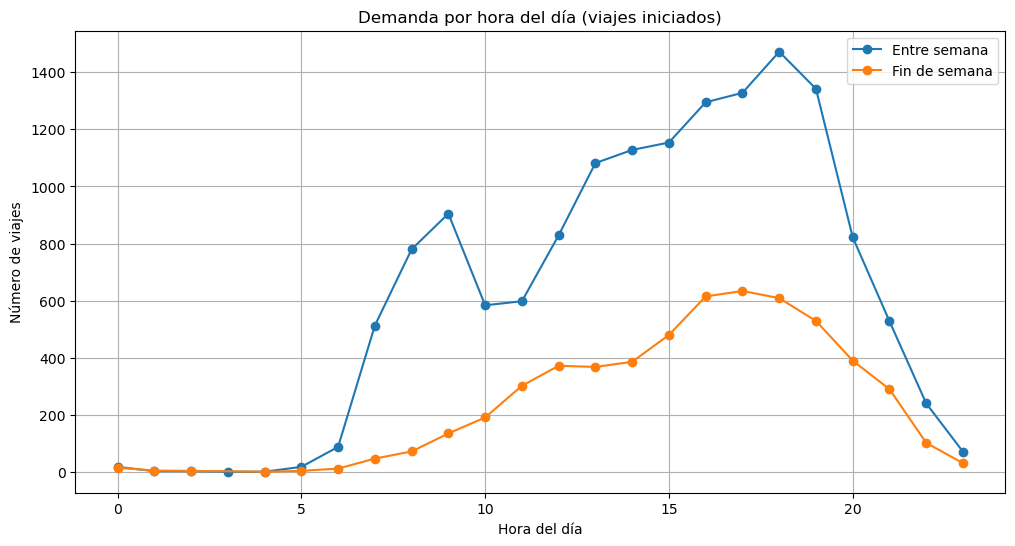

In [135]:
import matplotlib.pyplot as plt

# =====================================
# 2. Crear columnas: hora y día semana
# =====================================
df["hour_start"] = df["tsO"].dt.hour
df["hour_end"]   = df["tsD"].dt.hour

# Monday = 0 ... Sunday = 6
df["weekday"] = df["tsO"].dt.weekday

# ===============================
# 3. Clasificar weekday/weekend
# ===============================
df["day_type"] = df["weekday"].apply(lambda x: "weekday" if x < 5 else "weekend")

# =========================================
# 4. Demanda por hora (inicio de los viajes)
# =========================================

# Entre semana
demanda_inicio_weekday = (
    df[df["day_type"] == "weekday"]["hour_start"]
    .value_counts()
    .sort_index()
)

# Fin de semana
demanda_inicio_weekend = (
    df[df["day_type"] == "weekend"]["hour_start"]
    .value_counts()
    .sort_index()
)

# ========================
# 5. Gráfico comparativo
# ========================
plt.figure(figsize=(12,6))

plt.plot(demanda_inicio_weekday.index, demanda_inicio_weekday.values, 
         marker='o', label="Entre semana")

plt.plot(demanda_inicio_weekend.index, demanda_inicio_weekend.values, 
         marker='o', label="Fin de semana")

plt.title("Demanda por hora del día (viajes iniciados)")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes")
plt.grid(True)
plt.legend()
plt.show()


### **HEATMAP con la demanda por horas (En presentación final)**

In [136]:
# ============================
# 1. Asegurar tipo datetime
# ============================
df["tsO"] = pd.to_datetime(df["tsO"])

# ============================
# 2. Crear columna hora
# ============================
df["hour"] = df["tsO"].dt.hour

# ============================
# 3. Preparar datos por hora
# ============================
heat_data_hours = []

for h in range(24):
    df_hora = df[df["hour"] == h]
    heat_data = df_hora[["latO", "lonO"]].dropna().values.tolist()
    heat_data_hours.append(heat_data)

# ============================
# 4. Crear mapa base
# ============================
m = folium.Map(location=[41.9028, 12.4964], zoom_start=12)

# ============================
# 5. Añadir HeatMapWithTime
# ============================
HeatMapWithTime(
    data=heat_data_hours,
    index=[f"{h}:00" for h in range(24)],
    radius=12,
    auto_play=True,
    max_opacity=0.8
).add_to(m)

# ============================
# 6. Crear carpeta simulation2
# ============================
BASE = os.path.join(os.getcwd(), "simulation2")
os.makedirs(BASE, exist_ok=True)

# ============================
# 7. Guardar HTML dentro de simulation2
# ============================
output_file = os.path.join(BASE, "heatmap_horas.html")
m.save(output_file)

# ============================
# 8. Abrir en el navegador
# ============================
webbrowser.open("file://" + os.path.realpath(output_file))

print("✔ Heatmap guardado en:", output_file)

✔ Heatmap guardado en: c:\Users\Lenovo\OneDrive - Universidad Politécnica de Madrid\SERGIO2025_2026\Github\mobility-optimization\energetic_plan\simulation2\heatmap_horas.html


### **Simulación Batería ruta más larga (ejemplo)**

En esta simulación se usa la ruta más larga, que tiene una duración aproximada de 72 horas. En ella podremos ver como se van haciendo los viajes, con las coordenadas exactas, y cómo a medida que va haciendo los vaijes, la batería se va agotando. Tanto los estilos (css) cómo el fichero javascript se encuentran en una carpeta llamada simulation1. (**En presentación final**)

In [137]:

# Ruta correcta
BASE = os.path.join(os.getcwd(), "simulation1")
os.makedirs(BASE, exist_ok=True)

AUTONOMIA_KM = 42.6666666667
bateria_restante = AUTONOMIA_KM

patinete_top = (
    df.groupby("idS")["dis"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

df_p = df[df["idS"] == patinete_top].copy()
df_p = df_p.sort_values("tsO").reset_index(drop=True)

features = []
battery_levels = []

for viaje_idx, row in df_p.iterrows():

    distancia_km = row["dis"] / 1000
    bateria_restante = max(bateria_restante - distancia_km, 0)
    pct = bateria_restante / AUTONOMIA_KM * 100

    battery_levels.append(round(pct, 2))

    time_frame = f"2021-01-01T00:{viaje_idx:02d}:00"

    features.append({
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [row["lonO"], row["latO"]]},
        "properties": {"times": [time_frame]}
    })

centro = [df_p.iloc[0]["latO"], df_p.iloc[0]["lonO"]]
m = folium.Map(location=centro, zoom_start=13)

TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="PT05S",
    auto_play=True,
    loop=False
).add_to(m)

# Widget
battery_html = """
<div id="battery-box">
    <b>🔋 Batería</b><br>
    <div id="battery-bar">
        <div id="battery-fill"></div>
    </div>
    <span id="battery-text">100%</span>
</div>
"""

m.get_root().html.add_child(folium.Element(battery_html))

# Exportamos la lista a JS (ESTO VA EN <body>, NO EN HEAD)
m.get_root().html.add_child(folium.Element(
    f"<script>window.BATTERY_LEVELS = {battery_levels};</script>"
))

# Insertamos CSS EN EL HEAD (correcto)
m.get_root().header.add_child(folium.Element(
    '<link rel="stylesheet" href="styles.css">'
))

# Insertamos JS AL FINAL DEL BODY (correctísimo)
m.get_root().html.add_child(folium.Element(
    '<script src="battery.js"></script>'
))

output = os.path.join(BASE, "simulation1.html")
m.save(output)
webbrowser.open("file://" + os.path.realpath(output))

print("✔ Simulación creada en:", output)


✔ Simulación creada en: c:\Users\Lenovo\OneDrive - Universidad Politécnica de Madrid\SERGIO2025_2026\Github\mobility-optimization\energetic_plan\simulation1\simulation1.html


In [138]:
df.head()

,idS,tsO,tsD,price,Old Time,Old Dis,vel,lonO,latO,lonD,...,Osmnx Origen,Osmnx Destino,New Dis,dis,energy_wh,hour_start,hour_end,weekday,day_type,hour
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,2.1525,461,1715.336751,13.395254,12.466222,41.867388,12.470660,...,306297749,1119847027,1392.495456,1715.336751,23.157046,18,18,2,weekday,18
1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,1.6500,260,1234.472044,17.092690,12.471143,41.923692,12.467502,...,297720062,300084997,2324.982278,2324.982278,31.387261,18,18,5,weekend,18
2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,2.2225,489,2221.481536,16.354465,12.467524,41.934342,12.486330,...,300084997,291637771,4681.383030,4681.383030,63.198671,13,13,6,weekend,13
3,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,4.0000,1200,4562.843566,13.688531,12.486275,41.928301,12.457922,...,291637771,3577043693,5432.586749,5432.586749,73.339921,14,14,6,weekend,14
4,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,1.5025,201,550.154792,9.853519,12.457876,41.904303,12.460773,...,3577043693,246677431,726.153311,726.153311,9.803070,13,13,0,weekday,13


*FIN del breve EDA*

-----------------------------------------------------------------------------------------------------------------------------------------

# **FASE 0: NO STATIONS**, *(análisis del escenario pre estaciones (patinetes sueltos))*

#### **Probabilidad de que un patinete se quede sin batería** (de forma lineal y basándonos en los km)

En ausencia de estaciones, un patinete se queda sin batería si la energía disponible al inicio del viaje es menor que la energía que el viaje consume. *(suponemos que cada patinete comienza con el 100% de batería)*

In [139]:
df.head()

,idS,tsO,tsD,price,Old Time,Old Dis,vel,lonO,latO,lonD,...,Osmnx Origen,Osmnx Destino,New Dis,dis,energy_wh,hour_start,hour_end,weekday,day_type,hour
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,2.1525,461,1715.336751,13.395254,12.466222,41.867388,12.470660,...,306297749,1119847027,1392.495456,1715.336751,23.157046,18,18,2,weekday,18
1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,1.6500,260,1234.472044,17.092690,12.471143,41.923692,12.467502,...,297720062,300084997,2324.982278,2324.982278,31.387261,18,18,5,weekend,18
2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,2.2225,489,2221.481536,16.354465,12.467524,41.934342,12.486330,...,300084997,291637771,4681.383030,4681.383030,63.198671,13,13,6,weekend,13
3,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,4.0000,1200,4562.843566,13.688531,12.486275,41.928301,12.457922,...,291637771,3577043693,5432.586749,5432.586749,73.339921,14,14,6,weekend,14
4,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,1.5025,201,550.154792,9.853519,12.457876,41.904303,12.460773,...,3577043693,246677431,726.153311,726.153311,9.803070,13,13,0,weekday,13


In [140]:
df["tsO"] = pd.to_datetime(df["tsO"])
df = df.sort_values(["idS", "tsO"])

Simulación de descarga por patinete

In [141]:
CAPACIDAD_BATERIA = 576  # Esto quiere decir que la batería está llena

results = []

for id_pat, g in df.groupby("idS"):
    energia_restante = CAPACIDAD_BATERIA
    
    for _, row in g.iterrows():
        energia_restante -= row["energy_wh"]
        
        results.append({
            "idS": id_pat,
            "tsO": row["tsO"],
            "energy_wh": row["energy_wh"], #la enería que consume en ese viaje
            "energia_restante": energia_restante, # batería que le queda después del viaje
            "discharged": energia_restante < 0, # si se ha quedado sin batería al acabar
            "clusterOrigen": row["clusterOrigen"],
            "hour": row["hour"]
        })
        
        if energia_restante < 0:
            break  # el patinete ya no puede seguir circulando


In [142]:
df_sim = pd.DataFrame(results)
df_sim.head(10)

,idS,tsO,energy_wh,energia_restante,discharged,clusterOrigen,hour
0,A0H4,2021-02-03 18:10:03,23.157046,552.842954,False,174.0,18
1,A0H4,2021-02-13 18:21:13,31.387261,521.455693,False,59.0,18
2,A0H4,2021-02-14 13:39:54,63.198671,458.257022,False,98.0,13
3,A0H4,2021-02-14 14:37:53,73.339921,384.917101,False,137.0,14
4,A0H4,2021-02-15 13:31:24,9.803070,375.114031,False,113.0,13
5,A0H4,2021-02-15 14:12:43,23.908741,351.205291,False,179.0,14
6,A0H4,2021-02-17 17:18:33,21.761559,329.443732,False,64.0,17
7,A0H4,2021-02-18 08:02:04,17.031614,312.412118,False,56.0,8
8,A0H4,2021-02-18 21:26:14,72.751089,239.661029,False,178.0,21
9,A0H4,2021-02-19 11:52:34,16.636144,223.024885,False,22.0,11


% de patinetes que se quedan sin batería.

In [143]:
df_sim.groupby("idS")["discharged"].any().mean()

np.float64(0.060209424083769635)

Esto significa que aproximadamente el 6% de los patinetes del sistema se quedarían sin batería al menos una vez durante febrero en 2021, si no hubiera ningún tipo de recarga. Podemos verlo de otra forma cómo que el 94% de los patinetes no se descargan durante todo el periodo de febrero.

**ESTE DATO ES FUNDAMENTAL, YA QUE ESTAMOS HACIENDO TODO ESTE PROCESO DE ESTACIONARIZAR, PONIENDO ESTACIONES DE CARGA PARA EVITAR COGER UN PATINETE Y QUE ESTÉ DESCARGADO**. Además de para que esté todo organizado y no hayan patinetes sueltos por las calles. *(importante para la memoria)*

¿En qué viaje ocurre?

In [144]:
df_sim[df_sim["discharged"]].head()

,idS,tsO,energy_wh,energia_restante,discharged,clusterOrigen,hour
63,A0N7,2021-02-28 11:39:54,93.992005,-35.103666,True,3.0,11
120,A1E3,2021-02-23 19:34:03,81.382065,-39.738155,True,21.0,19
150,A1R8,2021-02-19 20:27:23,39.897661,-26.571464,True,155.0,20
453,A5E0,2021-02-22 08:45:13,68.693721,-20.048308,True,38.0,8
468,A5E7,2021-02-25 14:28:43,102.172868,-53.687172,True,79.0,14


Hacemos una visualización para que quede todo más claro. Creamos un nuevo df para evitar clisiones, además de que en el anteror no estaban las coordenadas.

In [145]:
cols_coords = ["idS", "tsO", "latO", "lonO", "latD", "lonD"]

df_fail = (
    df_sim[df_sim["discharged"]]
    .merge(df[cols_coords], on=["idS", "tsO"], how="left")
)

df_fail.head()

,idS,tsO,energy_wh,energia_restante,discharged,clusterOrigen,hour,latO,lonO,latD,lonD
0,A0N7,2021-02-28 11:39:54,93.992005,-35.103666,True,3.0,11,41.915293,12.523712,41.938181,12.465988
1,A1E3,2021-02-23 19:34:03,81.382065,-39.738155,True,21.0,19,41.916809,12.460644,41.912449,12.467133
2,A1R8,2021-02-19 20:27:23,39.897661,-26.571464,True,155.0,20,41.898302,12.463492,41.913659,12.458781
3,A5E0,2021-02-22 08:45:13,68.693721,-20.048308,True,38.0,8,41.876384,12.505255,41.904501,12.489940
4,A5E7,2021-02-25 14:28:43,102.172868,-53.687172,True,79.0,14,41.944547,12.461902,41.913307,12.517050


In [146]:
m = folium.Map(location=[41.9, 12.5], zoom_start=12)

for _, row in df_fail.iterrows():

    popup_text = f"""
    <b>Patinete:</b> {row['idS']}<br>
    <b>Fecha:</b> {row['tsO']}<br>
    <b>Hora:</b> {row['hour']}<br>
    <b>Energía viaje:</b> {row['energy_wh']:.1f} Wh<br>
    <b>Energía restante:</b> {row['energia_restante']:.1f} Wh<br>
    <b>Cluster origen:</b> {row['clusterOrigen']}
    """

    folium.PolyLine(
        locations=[
            [row["latO"], row["lonO"]],
            [row["latD"], row["lonD"]],
        ],
        color="red",
        weight=2,
        opacity=0.6
    ).add_to(m)

    folium.Marker(
        location=[row["latD"], row["lonD"]],
        popup=popup_text,
        icon=folium.Icon(color="red", icon="flash")
    ).add_to(m)

m.save("files/mapa_descargas.html")
webbrowser.open("file://" + os.path.abspath("files/mapa_descargas.html"))

True

Lo que se ven son los puntos concretos donde se quedó sin batería, junto con el inicio de la ruta (líneas)

Autonomía real antes de descarga. La distancia total recorrida por el patinete DESDE QUE EMPIEZA hasta que se descarga

In [147]:
df_sim["distance_km"] = df_sim["energy_wh"] / 13.5 #consumo lineal (dato dado)

df_sim[df_sim["discharged"]].groupby("idS")["distance_km"].sum().describe()

count    138.000000
mean       3.754429
std        2.081049
min        0.467513
25%        2.335427
50%        3.363788
75%        4.641840
max       13.930587
Name: distance_km, dtype: float64

- 138 patinetes que se descargaron
- Un patinete que se descarga, de media solo ha recorrido 3.75 km
- (50%) La mitad de los patinetes descargados recorrieron menos de 3.36 km antes de descargarse.
- (max) El mejor caso entre los que fallaron apenas llega a 14 km

Cluster en el que se descarga

In [148]:
df_sim[df_sim["discharged"]].groupby("clusterOrigen").size()


clusterOrigen
1.0      3
3.0      2
9.0      1
10.0     1
11.0     1
        ..
171.0    1
177.0    1
179.0    1
180.0    1
185.0    1
Length: 87, dtype: int64

Horas del día con mayor número de descargas

In [149]:
df_sim[df_sim["discharged"]].groupby("hour").size()


hour
5      2
7      5
8      5
9      5
10     9
11     7
12     9
13     5
14    14
15     8
16     9
17    17
18    13
19    13
20     7
21     6
22     3
23     1
dtype: int64

### Ahora nos hacemos la pregunta de ... si un usuario está por la calle y coge un patinete al azar, **¿cuál es la probabilidad real de que ese patinete esté descargado?**

Intervalo en el que un usuario podría llegar al sistema

In [150]:
t_start = df["tsO"].min()
t_end   = df["tsD"].max()
T_total = (t_end - t_start).total_seconds()

Nos quedamos solo con los viajes dond el patinete se descargó (si no se descragó el patinete no aparecerá)

In [151]:
t_descarga = (
    df_sim[df_sim["discharged"]]
    .groupby("idS")["tsO"]
    .min()
)

t_descarga

idS
A0N7   2021-02-28 11:39:54
A1E3   2021-02-23 19:34:03
A1R8   2021-02-19 20:27:23
A5E0   2021-02-22 08:45:13
A5E7   2021-02-25 14:28:43
               ...        
Z2I0   2021-02-23 16:14:53
Z2R8   2021-02-16 20:59:04
Z6E7   2021-02-28 18:40:23
Z9N9   2021-02-27 18:48:33
Z9W9   2021-02-25 12:50:13
Name: tsO, Length: 138, dtype: datetime64[ns]

Creamos la lista para guardar el tiempo que estará descargado cada patinete.

In [152]:
tiempo_descargado = []

In [153]:
for idS in df["idS"].unique():
    if idS in t_descarga: #el patinete se descarga
        td = (t_end - t_descarga[idS]).total_seconds()
    else: #no se descarga
        td = 0
    tiempo_descargado.append(td)

$$
P(\text{patinete descargado}) \;=\;
\frac{\text{Tiempo total descargado}}{\text{Tiempo total posible}}
$$

In [154]:
prob_pat_descargado = sum(tiempo_descargado) / (len(tiempo_descargado) * T_total)
print(f"La probabilidad de que un patinete esté descargado en un instante aleatorio es del {prob_pat_descargado * 100:.2f}%.")

La probabilidad de que un patinete esté descargado en un instante aleatorio es del 0.89%.


Calculamos los viajes afectados por descarga.

$$
P(\text{Viajes afectados por descarga}) \;=\;
\frac{\text{Nº de viajes que se descargan}}{\text{Nº total de viajes}}
$$

In [155]:
viajes_afectados_descarga = (
    df_sim[df_sim["discharged"]].shape[0] / df_sim.shape[0]
)
print(f"El {viajes_afectados_descarga * 100:.2f}% de los viajes se ven afectados por descargas.")

El 0.69% de los viajes se ven afectados por descargas.


Calculamos tiempo medio hasta descarga, esto que decir que, para cada patinete que se descarga, cuánto tiempo pasa desde que empieza a circular hasta que se queda sin batería por primera vez.

In [156]:
t_descarga = (
    df_sim[df_sim["discharged"]]
    .groupby("idS")["tsO"]
    .min()
)

In [157]:
t_inicio = df_sim.groupby("idS")["tsO"].min()

In [158]:
tiempo_hasta_descarga = (
    t_descarga - t_inicio[t_descarga.index]
).dt.total_seconds() / 3600

tiempo_hasta_descarga


idS
A0N7    643.066667
A1E3    508.913889
A1R8    439.366111
A5E0    446.905556
A5E7    570.300000
           ...    
Z2I0    343.171944
Z2R8    318.372500
Z6E7    534.025000
Z9N9    533.819167
Z9W9    544.872222
Name: tsO, Length: 138, dtype: float64

In [159]:
tiempo_medio_hasta_descarga = tiempo_hasta_descarga.mean()
print(f"El tiempo medio hasta la primera descarga de un patinete es de, {tiempo_medio_hasta_descarga:.2f} horas.")

El tiempo medio hasta la primera descarga de un patinete es de, 509.89 horas.


**509 horas** equivalen a **21 días** aproximadamente, lo que tiene todo el sentido con los datos que hemos ido recabando.

### *CONCLUSION:*
**A partir de esta análisis realizado, justificaremos la tarea pedida en este tercer proyecto de la asignatura, la colocacción de estaciones de recarga. ¿Tienen sentido? Además, también podremos justificar si se colocarán baterías para almacenar la enería, o si realmente no será necesario** 

### Escenario sin estaciones (Fase 0)


| Métrica | Valor |
|--------|-------|
| Probabilidad de coger un patinete descargado en instante aleatorio |**0,89%** |
| Probabilidad de patinetes que se queden sin batería | 138 de 2292 = **6%** |
| Tiempo medio hasta descarga | 509 h |
| Viajes afectados por descarga | **0,69%** |
| Hora más crítica | 17:00 |
| Zona más crítica | Cluster 1 |


Por tanto, creemos que desde un punto de vista meramente global, la ausencia de estaciones no genera un problema crítico de la disponibilidad de patinetes. Aún así cómo se nos ha pedido, y nuestro objetivo es eliminar los fallos residuales, y preparar un posible escalado del sistema, en la siguiente fase jsutificaremos la implantación de las mismas.

Limpiamos y cargamos nuevo dataset para continuar trabajando

In [160]:
df.drop(
    columns=["hour_start", "hour_end", "weekday", "day_type", "hour", "Old Dis", "New Dis"],
    errors="ignore",
    inplace=True
)
df.columns

Index(['idS', 'tsO', 'tsD', 'price', 'Old Time', 'vel', 'lonO', 'latO', 'lonD',
       'latD', 'clusterOrigen', 'clusterFinal', 'Lat ClusterOrigin',
       'Lon ClusterOrigin', 'Lat ClusterDest', 'Lon ClusterDest',
       'Osmnx Origen', 'Osmnx Destino', 'dis', 'energy_wh'],
      dtype='object')

In [161]:
df.to_csv("files/df_distancias_finales.csv", index=False)